# 🚀 Detecção de Objetos com YOLOS-Tiny

Este notebook utiliza o modelo `hustvl/yolos-tiny` da biblioteca `transformers` (Hugging Face) para detectar objetos nas imagens da pasta `../imagens`.

In [1]:
# Install dependencies
%pip install transformers torch torchvision pillow matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 🛠️ Configuração e Carregamento do Modelo

Vamos carregar o processador e o modelo pré-treinado `hustvl/yolos-tiny`.

In [2]:
from transformers import YolosImageProcessor, YolosForObjectDetection
import torch
from PIL import Image, ImageDraw, ImageFont
import os
import matplotlib.pyplot as plt

# Configurações
MODEL_NAME = "hustvl/yolos-tiny"
IMAGES_DIR = r'C:\Users\ivanu\Desktop\recog_system\imagens'
THRESHOLD = 0.6 # Limite de confiança para exibir a detecção

# Carregar processador e modelo
print(f"Carregando modelo {MODEL_NAME}...")
image_processor = YolosImageProcessor.from_pretrained(MODEL_NAME)
model = YolosForObjectDetection.from_pretrained(MODEL_NAME)
print("Modelo carregado com sucesso!")

c:\Users\ivanu\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Carregando modelo hustvl/yolos-tiny...


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 5625.61it/s]

Modelo carregado com sucesso!


## 🖼️ Processamento das Imagens

Agora vamos percorrer a pasta `imagens`, aplicar a detecção e exibir os resultados com bounding boxes.


Processando: bird.jpg...
{'scores': tensor([0.9958]), 'labels': tensor([16]), 'boxes': tensor([[ 586.3057,  276.1509, 2846.4775, 2448.4465]])}
Detectado bird com confiança 1.00 em [586.31, 276.15, 2846.48, 2448.45]


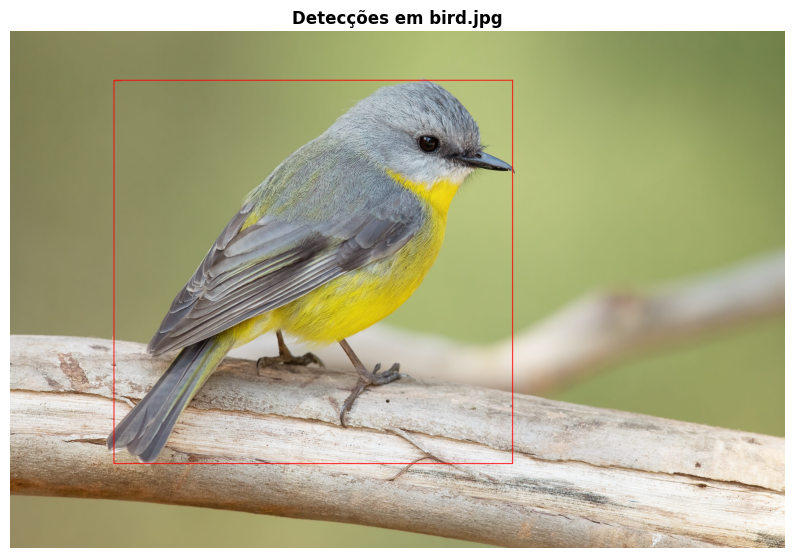


Processando: cats_dog.png...
{'scores': tensor([0.9381, 0.7871, 0.9753, 0.9041, 0.9994, 0.8019, 0.7129]), 'labels': tensor([18, 65, 65, 18, 17, 17, 18]), 'boxes': tensor([[ 2.3767e+02,  1.1786e+02,  7.4891e+02,  5.1546e+02],
        [-8.9407e-03,  1.6834e+02,  9.9997e+02,  5.5472e+02],
        [ 2.6375e-02,  1.4298e+02,  9.9971e+02,  5.5345e+02],
        [ 2.4127e+02,  1.1852e+02,  7.1614e+02,  5.0092e+02],
        [ 6.5380e+02,  1.3213e+02,  8.6752e+02,  4.6193e+02],
        [ 5.5260e+01,  2.5409e+02,  3.8673e+02,  4.9614e+02],
        [ 2.3981e+02,  1.2207e+02,  6.7147e+02,  4.5355e+02]])}
Detectado dog com confiança 0.94 em [237.67, 117.86, 748.91, 515.46]
Detectado bed com confiança 0.79 em [-0.01, 168.34, 999.97, 554.72]
Detectado bed com confiança 0.98 em [0.03, 142.98, 999.71, 553.45]
Detectado dog com confiança 0.90 em [241.27, 118.52, 716.14, 500.92]
Detectado cat com confiança 1.00 em [653.8, 132.13, 867.52, 461.93]
Detectado cat com confiança 0.80 em [55.26, 254.09, 386.73,

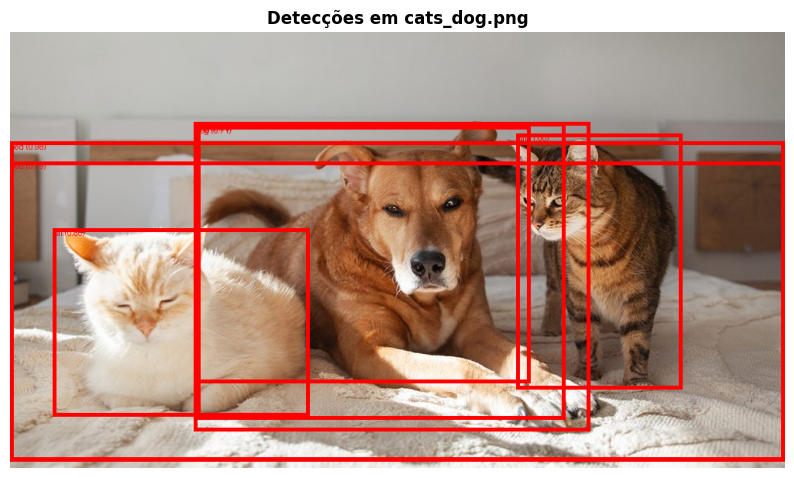


Processando: kitchen.png...
{'scores': tensor([0.8312, 0.9295, 0.9626, 0.9402, 0.9619, 0.8599, 0.6437, 0.7537, 0.9108,
        0.7708, 0.9478, 0.9376, 0.9003, 0.8676, 0.6496, 0.6069, 0.7411]), 'labels': tensor([49, 79, 49, 79, 64, 49, 51, 49, 86, 49, 49, 49, 49, 64, 64, 50, 64]), 'boxes': tensor([[685.8432, 164.7491, 702.1572, 274.2051],
        [414.6694, 343.3986, 647.0361, 489.6017],
        [694.6014, 163.3593, 715.2156, 277.2478],
        [418.1333, 395.3373, 638.2932, 490.8495],
        [ 59.0594, 187.6724, 170.7999, 365.7413],
        [704.0000, 162.3328, 723.9434, 279.4078],
        [416.7042, 336.0568, 465.6367, 365.6690],
        [703.3510, 170.7289, 725.8986, 281.2796],
        [ 98.6029, 268.0567, 136.8560, 363.3585],
        [691.2881, 163.1180, 706.8190, 276.6374],
        [678.5311, 163.8593, 694.2406, 273.8777],
        [668.9682, 164.8402, 684.2819, 270.2448],
        [674.7432, 163.2170, 689.7798, 276.2122],
        [516.0400, 257.5693, 674.1437, 340.9919],
        [

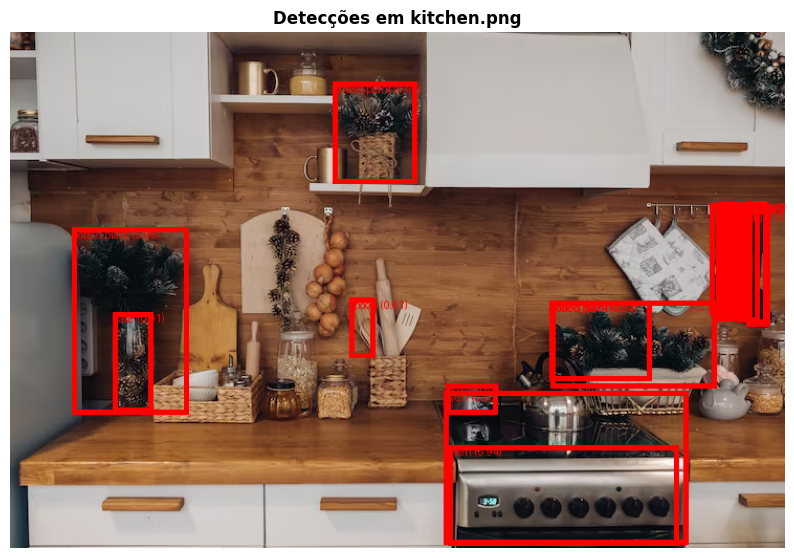


Processando: pizza.png...
{'scores': tensor([0.6181, 0.6184, 0.6502, 0.9271, 0.9307, 0.6513, 0.8763, 0.6320, 0.8668,
        0.8277, 0.8982, 0.7093]), 'labels': tensor([59, 59, 59, 59, 59, 59, 67, 59, 59, 59, 59, 59]), 'boxes': tensor([[2.6172e+02, 1.7036e+02, 1.0118e+03, 9.2829e+02],
        [6.7614e+00, 1.7904e+02, 5.0603e+02, 4.8737e+02],
        [1.4258e+01, 1.1218e+02, 9.9835e+02, 9.2875e+02],
        [2.7191e+02, 5.2913e+02, 8.7554e+02, 9.2816e+02],
        [2.2185e+01, 4.2985e+02, 5.0284e+02, 8.7591e+02],
        [2.9809e+02, 1.1755e+02, 7.9093e+02, 4.6419e+02],
        [1.8314e-01, 2.5503e+00, 1.0239e+03, 9.6057e+02],
        [3.1521e+02, 1.1079e+02, 8.0923e+02, 5.5779e+02],
        [5.3876e+02, 2.1057e+02, 1.0231e+03, 7.8427e+02],
        [2.5753e+02, 4.2906e+02, 9.0566e+02, 9.3086e+02],
        [3.5164e+02, 1.1487e+02, 7.7226e+02, 4.6718e+02],
        [5.9611e+02, 2.0034e+02, 1.0198e+03, 4.9863e+02]])}
Detectado pizza com confiança 0.62 em [261.72, 170.36, 1011.83, 928.29]
D

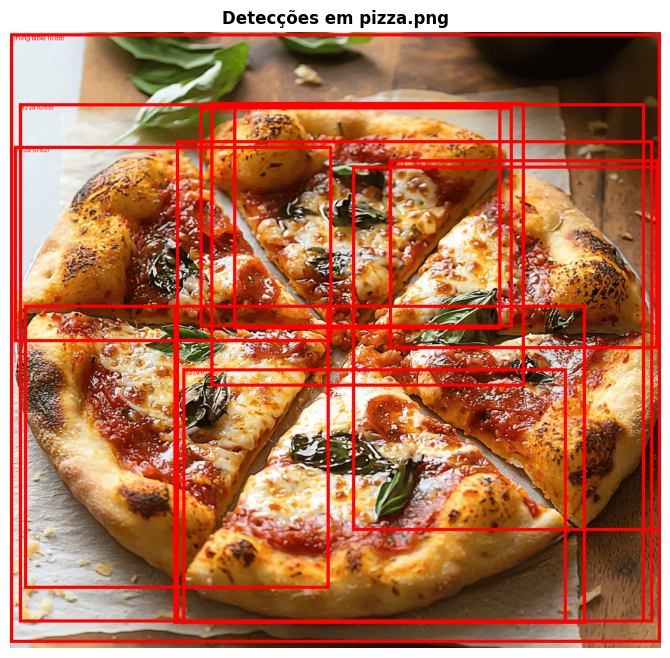

In [3]:
def detect_objects(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = image_processor(images=image, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model(**inputs)
        
    target_sizes = torch.tensor([image.size[::-1]])
    results = image_processor.post_process_object_detection(outputs, threshold=THRESHOLD, target_sizes=target_sizes)[0]
    return image, results

valid_exts = (".png", ".jpg", ".jpeg")
image_files = [f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(valid_exts)]

for img_name in image_files:
    full_path = os.path.join(IMAGES_DIR, img_name)
    print(f"\nProcessando: {img_name}...")
    
    image, results = detect_objects(full_path)
    print(results)

    draw = ImageDraw.Draw(image)
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        box = [round(i, 2) for i in box.tolist()]
        label_name = model.config.id2label[label.item()]
        conf = f"{score.item():.2f}"
        
        draw.rectangle(box, outline="red", width=5)
        draw.text((box[0], box[1]), f"{label_name} ({conf})", fill="red")
        print(f"Detectado {label_name} com confiança {conf} em {box}")
        
    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.title(f"Detecções em {img_name}", fontweight='bold')
    plt.axis("off")
    plt.show()